# Model agreement vs LLM judges on long rule sentences (R_COMP)

**Question.** Given an English rule sentence and a candidate first-order-logic (FOL) translation, and **no gold formula**,
can we predict whether the translation is faithful?

**This artifact** compares two gold-free signals on *R_COMP*: 221 templated long rule sentences (≥25 words, ≥3 conditions,
one *unless / except / provided that / only if* clause). Each sentence was translated by 10 few-shot LLM slots from 9 model
families. In the **SIG** condition the prompt fixes the predicate signature, so every translation uses the same names and
correctness is labelled by **pure z3 equivalence** to the weak or strong template reading.

* **Cross-family consensus** `c_score_sig` = share of *family-disjoint* peer translations that are **not** z3-equivalent to the
  candidate (0 = everyone agrees, 1 = nobody agrees; higher = more likely an error). No LLM call, just a solver.
* **LLM-as-judge** baselines: a cheap `gemini-2.5-flash-lite` rubric judge (on a *disguised* and on the original text), a local
  Qwen3-8B judge and a frontier `gemini-3.1-pro` judge on a subsample.

**Pre-registered primary test (full run, 1,904 rows / 220 sentences):** within-template AUROC of `c_score_sig` = **0.954** vs the
disguised cheap judge **0.587**, delta **+0.367 [0.328, 0.404]** → PASS.

**What this notebook does** (the original `method.py` is an orchestrator whose own compute step is `build()`; the stages it
calls live in `src/`):
1. loads a curated subset (10 sentences × 10 translations = 100 rows) with labels and all pre-computed scores;
2. re-computes the consensus metric **live with z3** using the artifact's reusable `consensus_exact()` function;
3. runs `method.py`'s `build()` step to assemble `method_out.json` (exp_gen_sol_out format);
4. runs the primary-test machinery from `src/analyse.py` / `src/auc_tools.py` (within-template AUROC, sentence-clustered
   template-stratified bootstrap) on the subset;
5. plots the results next to the full-run numbers.

LLM generation and LLM judging (stages S3-S9) cost money and API keys, so their outputs are loaded from the data file rather than re-run.

## Setup
Install the packages that are not on Colab (`z3-solver`, `loguru`); the core scientific stack is installed at Colab's versions only when running outside Colab.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT on Colab, always install
_pip('z3-solver==4.15.4.0', 'loguru==0.7.3')

# numpy, pandas, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

Imports: the original `method.py` import block, plus what the copied `src/` helpers (`fol.py`, `consensus_rcomp.py`, `auc_tools.py`, `analyse.py`) and the plots need.

In [2]:
# --- original method.py imports ---
import argparse
import json
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- imports of the copied helpers (fol.py, consensus_rcomp.py, auc_tools.py, analyse.py) ---
import hashlib
import re
import signal
import time
from collections import Counter, defaultdict

import numpy as np
import z3

# --- notebook-only: results table and plots ---
import pandas as pd
import matplotlib.pyplot as plt

## Data loading
The curated subset is fetched from GitHub, with a local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-3/experiment-7/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{len(data['sentences'])} sentences, {len(data['rows'])} candidate rows")
print("labels:", dict(Counter(r["label"] for r in data["rows"])))

Curated R_COMP-SIG subset: 10 long rule sentences (one per template T1-T9 + one extra with non-pool labels), each with its 10 few-shot LLM translations (100 candidate rows) carrying z3 labels, consensus scores and LLM-judge scores. Sentences picked for having both ERROR and CORRECT translations, so the subset is error-enriched relative to the full 221-sentence set.
10 sentences, 100 candidate rows
labels: {'ERROR': 38, 'UNPARSEABLE': 1, 'CORRECT': 56, 'OFF_SIGNATURE': 4, 'READING_CHOICE': 1}


## Config
All tunable parameters. `N_SENTENCES` picks how many of the 10 demo sentences are used (each brings its 10 translations);
`B` is the number of bootstrap replicates. The original values are noted in the comments.

In [5]:
N_SENTENCES = 10   # demo sentences used (max 10 in mini_demo_data.json); original run: 221 R_COMP sentences
B = 2000              # bootstrap replicates for the AUROC CIs; original: 2000
Z3_MS = 5000        # per-pair z3 timeout in ms (original: 5000)
PAIR_CAP_S = 30     # wall-clock cap per z3 pair in seconds (original: 30)

## `method.py`: paths, logging and output schema
Constants from the original entry point. `ROOT/RES/RC` pointed at the artifact's `results/` and `rcomp/` folders; here the
inputs come from `data` instead, so they are kept only as the notebook's working directory. The rotating file log sink is
dropped (no `logs/` folder in the notebook). `PRED` lists every score column (all oriented **higher = more likely ERROR**),
`META` the per-row metadata copied into `method_out.json`.

In [6]:
ROOT = Path(".")          # original: Path(__file__).resolve().parent
RES = ROOT / "results"    # original inputs; replaced by `data` in this notebook
RC = ROOT / "rcomp"

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")   # file sink not used in the notebook

PRED = ["c_score_sig", "c_score_align", "c_score_nf", "c_score_hyb", "g_align", "g_nf", "judge_cheap_disg", "judge_cheap_orig",
        "judge_frontier_orig", "judge_frontier_disg", "judge_local_disg", "judge_local_orig"]
META = ["row_key", "item_id", "sentence_id", "template_id", "slot", "system", "family", "prompt_variant", "parse_ok",
        "label_source", "label_tier", "matched_reading", "off_signature", "sig_status", "repair_ops", "repair_status",
        "sig_class_id", "sig_class_id_size", "sig_class_id_n_peers", "sig_class_id_n_peers_same_class",
        "sig_class_id_peer_majority_class", "sig_class_id_is_peer_majority", "free_solver_class_id", "free_align_class_id",
        "free_hyb_class_id", "free_align_class_id_size", "free_align_class_id_is_peer_majority", "free_hyb_class_id_size",
        "free_hyb_class_id_is_peer_majority", "n_peers_sig", "n_peers_equal_sig", "n_unknown_sig", "n_peers_hyb",
        "correct_not_equivalent", "ref_flagged", "tier_B_provisional", "cost_usd", "secs_sig", "coverage_status"]


def run(cmd: list[str]) -> None:
    logger.info("$ " + " ".join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)


def fmt_pred(v) -> str:
    return "None" if v is None else f"{float(v):.6f}"

## FOL parser and z3 equivalence (`rcomp/labeller/fol.py`)
The consensus metric and the labels both rest on this module: a precedence-climbing parser for Unicode FOL
(`∀ ∃ ¬ ∧ ∨ ⊕ → ↔`, FOLIO/MALLS conventions) that builds an AST and translates it to z3 over one uninterpreted sort `U`.
`equivalent(e1, e2)` asks z3 whether `e1 ↔ e2` is valid (returns `True` / `False` / `None` on timeout). Copied verbatim.

In [7]:
TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
IDENT = re.compile(r"^[A-Za-z_][A-Za-z0-9_'\-]*$")
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}  # FIX (gen_art_dataset_1): ⊕ moved to the ∨ level, binds tighter than →


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("<->", "↔").replace("->", "→").replace("&", "∧").replace("|", "∨")  # FIX: <-> before ->
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if name is None or not IDENT.match(name):  # FIX (gen_art_dataset_1): truncated input used to yield atom None
            raise ValueError(f"expected identifier, got {name!r}")
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            if any(a is None or not IDENT.match(a) for a in args):
                raise ValueError(f"bad argument list {args!r}")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def profile(e, ms=3000):
    """Semantic monotonicity of formula e in each predicate: UP / DOWN / VACUOUS / NONMONO / UNKNOWN."""
    ar = preds(e)
    base = {q: mkpred(q, m) for q, m in ar.items()}
    out = {}
    for p, n in ar.items():
        alt = dict(base)
        alt[p] = mkpred(p + "_prime", n)
        xs = [z3.Const(f"_x{i}", U) for i in range(n)]
        sub = z3.ForAll(xs, z3.Implies(base[p](*xs), alt[p](*xs))) if n else z3.Implies(base[p], alt[p])
        F, Fp = to_z3(e, {}, base), to_z3(e, {}, alt)
        up, down = valid(z3.Implies(z3.And(sub, F), Fp), ms), valid(z3.Implies(z3.And(sub, Fp), F), ms)
        if up is None or down is None:
            out[p] = "UNKNOWN"
        else:
            out[p] = {(True, True): "VACUOUS", (True, False): "UP", (False, True): "DOWN", (False, False): "NONMONO"}[(up, down)]
    return out


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)

## The metric: `consensus_exact` (`src/consensus_rcomp.py`)
**What it measures.** For a candidate formula and the translations of the *same* sentence by *other* model families, the
share of those peers that are **not** logically equivalent to the candidate (z3, both directions, per-pair timeout).
An unparseable or timed-out peer counts as "not agreeing". It is valid only when all translations share one signature
(the SIG condition): renaming a predicate makes a correct formula disagree with everyone. Copied verbatim; the two
`from fol import ...` lines are commented out because the parser is defined in the cell above.

In [8]:
class _Timeout(Exception):
    pass


def _alarm(signum, frame):  # noqa: ARG001
    raise _Timeout()


def _equiv(a, b, ms: int, cap_s: int):
    # from fol import equivalent   (notebook: defined in the parser cell above)
    old = signal.signal(signal.SIGALRM, _alarm)
    signal.alarm(cap_s)
    try:
        return equivalent(a, b, ms)
    except _Timeout:
        return None
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old)


def consensus_exact(fol: str, peers: list[str], ms: int = 5000, pair_cap_s: int = 30, return_details: bool = False):
    """Share of family-disjoint peers NOT z3-equivalent to `fol` under identical vocabulary (see module docstring).

    fol   : candidate formula (dataset-E FOL syntax: ∀ ∃ ¬ ∧ ∨ → ↔, Pred(x, const)).
    peers : translations of the same sentence by OTHER model families (the caller enforces family-disjointness).
    Returns a float in [0, 1] (None if the candidate is unparseable or fewer than 2 peers), or a dict with details.
    """
    # from fol import parse        (notebook: defined in the parser cell above)
    try:
        c = parse(fol)
    except Exception:  # noqa: BLE001 - the parser raises assorted errors on junk
        return {"score": None, "reason": "unparseable"} if return_details else None
    if len(peers) < 2:
        return {"score": None, "reason": "fewer than 2 peers"} if return_details else None
    eqs = []
    for p in peers:
        try:
            pe = parse(p)
        except Exception:  # noqa: BLE001
            eqs.append(False)
            continue
        eqs.append(True if str(pe) == str(c) else _equiv(c, pe, ms, pair_cap_s))
    score = 1 - sum(e is True for e in eqs) / len(eqs)
    if return_details:
        return {"score": score, "n_peers": len(eqs), "n_equal": sum(e is True for e in eqs), "n_unknown": sum(e is None for e in eqs)}
    return score

## Recompute consensus live on the demo rows
The peer pool follows `src/score_consensus.py`: parseable few-shot rows from a **different vendor family** (the
`FAM` map below, from `src/analyse.py`; `G1`/`G1b` are both Meta and `G5`/`G8` both Google, so they never vote for each other).
The original scorer additionally canonicalised each formula onto the given signature (`label_sig.canon_case`: case-insensitive
name matching, off-signature formulas get no score). `consensus_exact` skips that step, so a few rows can differ from the
stored `c_score_sig`; the cell reports how many match.

In [9]:
SEED = 20260924
FEW = ["G1", "G1b", "G2", "G3", "G4", "G5", "G6", "G7", "G8", "G9"]
FAM = {"G1": "meta", "G1b": "meta", "G2": "qwen", "G3": "mistral", "G4": "deepseek", "G5": "google", "G8": "google",
       "G6": "microsoft", "G7": "openai", "F": "openai", "G9": "cohere"}  # exp-5 family_map_vendor
CONS = ["c_score_sig", "c_score_align", "c_score_nf", "c_score_hyb", "g_align", "g_nf"]
JUDGES = ["judge_cheap_disg", "judge_cheap_orig", "judge_frontier_orig", "judge_frontier_disg", "judge_local_disg",
          "judge_local_orig"]
METRICS = CONS + JUDGES
PRIMARY_BAR = "judge_cheap_disg"

sel_ids = [s["sentence_id"] for s in data["sentences"][:N_SENTENCES]]
rows = [r for r in data["rows"] if r["sentence_id"] in sel_ids]
print(f"using {len(sel_ids)} sentences / {len(rows)} rows")

t0 = time.time()
for sid in sel_ids:
    task = [r for r in rows if r["sentence_id"] == sid]
    pool = [r for r in task if r["slot"] in FEW and r["parse_ok"]]
    for r in task:
        peers = [p["candidate_fol"] for p in pool if FAM[p["slot"]] != FAM[r["slot"]] and p["row_key"] != r["row_key"]]
        d = consensus_exact(r["candidate_fol"] or "", peers, ms=Z3_MS, pair_cap_s=PAIR_CAP_S, return_details=True)
        r["c_score_exact_live"] = d["score"]
print(f"z3 consensus for {len(rows)} rows in {time.time() - t0:.1f}s")

both = [r for r in rows if r["c_score_exact_live"] is not None and r["c_score_sig"] is not None]
same = sum(abs(r["c_score_exact_live"] - r["c_score_sig"]) < 1e-9 for r in both)
print(f"live consensus_exact == stored c_score_sig on {same}/{len(both)} rows scored by both")
for r in rows:
    if r["c_score_exact_live"] is not None and r["c_score_sig"] is not None and abs(r["c_score_exact_live"] - r["c_score_sig"]) > 1e-9:
        print(f"  differs: {r['row_key']:<28} label={r['label']:<14} live={r['c_score_exact_live']:.3f} stored={r['c_score_sig']:.3f} sig_status={r['sig_status']}")

using 10 sentences / 100 rows


z3 consensus for 100 rows in 1.8s
live consensus_exact == stored c_score_sig on 95/95 rows scored by both


### One sentence, its two readings and ten translations

In [10]:
s0 = next(s for s in data["sentences"] if s["sentence_id"] == sel_ids[0])
print("TEXT  :", s0["text"])
print("WEAK  :", s0["reference_fol_weak"])
print("STRONG:", s0["reference_fol_strong"])
print()
for r in [r for r in rows if r["sentence_id"] == sel_ids[0]]:
    live = "None" if r["c_score_exact_live"] is None else f"{r['c_score_exact_live']:.2f}"
    jd = "None" if r["judge_cheap_disg"] is None else f"{r['judge_cheap_disg']:.2f}"
    print(f"{r['slot']:<4} {r['family']:<10} {r['label']:<14} reading={str(r['matched_reading']):<6} consensus={live:<5} judge={jd:<5} {r['candidate_fol'][:110]}")

TEXT  : Each graduate student who is criticized by their boss, who can use the left foot very efficiently, and who lives in cramped residential buildings is an employee in James's town, except if the graduate student has a temporary role at the orchestra.
WEAK  : ∀x (GraduateStudent(x) ∧ CriticizedBy(x, boss) ∧ UseEfficiently(x, leftFoot) ∧ LiveIn(x, crampedBuilding) ∧ ¬HaveTemporaryRoleAt(x, theOrchestra) → EmployeeIn(x, jamesSTown))
STRONG: ∀x (GraduateStudent(x) ∧ CriticizedBy(x, boss) ∧ UseEfficiently(x, leftFoot) ∧ LiveIn(x, crampedBuilding) → (EmployeeIn(x, jamesSTown) ↔ ¬HaveTemporaryRoleAt(x, theOrchestra)))

G1   meta       ERROR          reading=None   consensus=0.88  judge=0.80  ∀x (GraduateStudent(x) ∧ CriticizedBy(x, boss) ∧ UseEfficiently(x, leftFoot) ∧ LiveIn(x, crampedBuilding) → (E
G1b  meta       UNPARSEABLE    reading=None   consensus=None  judge=None  ∀x (GraduateStudent(x) ∧ CriticizedBy(x, boss) ∧ UseEfficiently(x, leftFoot) ∧ LiveIn(x, crampedBuilding) → (∃
G2   

## `method.py build()`: assemble `method_out.json`
The original `build()` joins the per-row candidate file with the sentence texts and the analysis summary and writes the
exp_gen_sol_out JSON (one example per candidate; `predict_*` = every score, `metadata_*` = labels, strata, class ids).
Only the three file reads are replaced by the loaded `data` (restricted to the `N_SENTENCES` selection); the metadata's
`primary_test` block therefore still reports the **full-run** analysis, exactly as the original does.

In [11]:
@logger.catch(reraise=True)
def build() -> None:
    sents = {s["sentence_id"]: s for s in data["sentences"]}          # original: rcomp/work/rcomp_sentences.json
    rows = [r for r in data["rows"] if r["sentence_id"] in sel_ids]    # original: results/rcomp_candidates.jsonl
    A = data["analysis_full_run"]                                     # original: results/analysis.json
    ds = {"SIG": [], "FREE": []}
    for r in rows:
        s = sents[r["sentence_id"]]
        ex = {"input": json.dumps({"text": s["text"], "candidate_fol": r.get("candidate_fol") or "", "condition": r["condition"]}, ensure_ascii=False),
              "output": str(r["label"])}
        for m in PRED:
            ex[f"predict_{m}"] = fmt_pred(r.get(m))
        for k in META:
            v = r.get(k)
            ex[f"metadata_{k}"] = v
        for k, v in (r.get("strata") or {}).items():
            ex[f"metadata_{k}"] = v
        ex["metadata_condition"] = r["condition"]
        ds[r["condition"]].append(ex)
    sig = A["SIG"]
    meta = {"method_name": "cross-family consensus (SIG-exact, ALIGN, NF-anchored, HYB, graded) vs LLM judges on R_COMP",
            "orientation": "every predict_* score: higher = more likely ERROR; 'None' = not computed (see metadata)",
            "labels": {"SIG": "pure z3 equivalence to the weak or strong template reading (CORRECT / ERROR / READING_CHOICE / OFF_SIGNATURE / UNPARSEABLE)",
                       "FREE": "dataset-3 solver-modulo-alignment rule, tier A only (panel not run, deviation D9): CORRECT / ERROR / UNRESOLVED / UNPARSEABLE / NO_OUTPUT"},
            "primary_test": {k: sig["primary"].get(k) for k in ("n", "n_error", "n_correct", "n_sentences", "auroc_metric", "auroc_comparator",
                                                              "delta", "ci", "p_one_sided", "PASS")},
            "testability": {"SIG": data["testability"]["SIG"],       # original: results/testability_SIG.json
                            "FREE": data["testability"]["FREE"]},    # original: results/testability_FREE.json
            "frozen_params": "exp-5 prereg scoring_params (variants ALIGN + NF-anchored, k=5, tau 0.5, timeout 2000 ms, pair cap 30 s); no tuning on R_COMP",
            "results_files": ["results/analysis.json", "results/tables.md", "results/rcomp_candidates.jsonl", "results/deviations.json"]}
    out = {"metadata": meta, "datasets": [{"dataset": "R_COMP_SIG", "examples": ds["SIG"]}]}
    if ds["FREE"]:
        out["datasets"].append({"dataset": "R_COMP_FREE", "examples": ds["FREE"]})
    (ROOT / "method_out.json").write_text(json.dumps(out, ensure_ascii=False, indent=1))
    logger.info(f"method_out.json: SIG {len(ds['SIG'])} rows, FREE {len(ds['FREE'])} rows")

build()
mo = json.loads((ROOT / "method_out.json").read_text())
ex0 = mo["datasets"][0]["examples"][0]
print({k: v for k, v in ex0.items() if k == "output" or k.startswith("predict_")})

16:35:49|INFO   |method_out.json: SIG 100 rows, FREE 0 rows


{'output': 'ERROR', 'predict_c_score_sig': '0.875000', 'predict_c_score_align': '0.875000', 'predict_c_score_nf': '0.875000', 'predict_c_score_hyb': '0.875000', 'predict_g_align': '0.777778', 'predict_g_nf': '0.777778', 'predict_judge_cheap_disg': '0.800000', 'predict_judge_cheap_orig': '0.050000', 'predict_judge_frontier_orig': 'None', 'predict_judge_frontier_disg': 'None', 'predict_judge_local_disg': '0.100000', 'predict_judge_local_orig': '0.100000'}


## Primary test machinery (`src/auc_tools.py`, `src/analyse.py`)
`StratAUC` computes the **within-stratum AUROC**: ERROR×CORRECT pairs are compared only inside the same template, so the metric
cannot win by separating easy templates from hard ones. `boot_weights` resamples sentences with replacement *within* each
template (sentence-clustered, template-stratified bootstrap). `delta_block` returns AUROC(metric) − AUROC(comparator) with a
paired bootstrap CI. All copied verbatim.

In [12]:
class StratAUC:
    """Precomputes per-stratum score ranks once; value(cluster_weights) is then O(n) per replicate."""

    def __init__(self, score: np.ndarray, is_err: np.ndarray, stratum: np.ndarray, cluster: np.ndarray,
                 stratum_is_cluster: bool = False):
        score = np.asarray(score, dtype=float)
        is_err = np.asarray(is_err, dtype=bool)
        self.linear = stratum_is_cluster
        self.parts = []
        for s in np.unique(stratum):
            m = stratum == s
            y = is_err[m]
            if y.all() or (~y).all():
                continue
            u, g = np.unique(score[m], return_inverse=True)
            self.parts.append((g.astype(np.int64), y, cluster[m], len(u)))

    def value(self, cw: np.ndarray | None = None) -> float:
        U = P = 0.0
        for g, y, cl, ng in self.parts:
            if cw is None:
                w = np.ones(len(g))
            else:
                w = cw[cl].astype(float)
                if self.linear:
                    w = np.sqrt(w)
            negw = np.bincount(g[~y], w[~y], minlength=ng)
            posw = np.bincount(g[y], w[y], minlength=ng)
            below = np.cumsum(negw) - negw
            U += float((posw * (below + 0.5 * negw)).sum())
            P += float(posw.sum() * negw.sum())
        return U / P if P > 0 else float("nan")

    def n_pairs(self) -> int:
        return int(sum(int(y.sum()) * int((~y).sum()) for _, y, _, _ in self.parts))


def boot_weights(cluster_stratum: np.ndarray, B: int, seed: int) -> np.ndarray:
    """(B, n_clusters) integer multiplicities; clusters resampled with replacement within their stratum (template)."""
    rng = np.random.default_rng(seed)
    n = len(cluster_stratum)
    W = np.zeros((B, n), dtype=np.int32)
    groups = [np.flatnonzero(cluster_stratum == s) for s in np.unique(cluster_stratum)]
    for b in range(B):
        for idx in groups:
            draw = rng.choice(idx, size=len(idx), replace=True)
            np.add.at(W[b], draw, 1)
    return W


def summarize(point: float, boots: np.ndarray) -> dict:
    boots = boots[~np.isnan(boots)]
    if len(boots) == 0:
        return {"est": point, "ci": [None, None], "se": None, "n_boot": 0}
    return {"est": point, "ci": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))],
            "se": float(np.std(boots, ddof=1)), "n_boot": int(len(boots))}

In [13]:
class Ctx:
    """Per condition: sentence index + ONE set of bootstrap weights (paired across every metric and comparison)."""

    def __init__(self, rows: list[dict], B: int):
        sids = sorted({r["sentence_id"] for r in rows})
        self.sidx = {s: i for i, s in enumerate(sids)}
        tm = {r["sentence_id"]: r["template_id"] for r in rows}
        self.W = boot_weights(np.array([tm[s] for s in sids]), B, SEED)
        self.B = B


def _arrays(ctx: Ctx, rows: list[dict], key: str, stratum: str):
    s = np.array([r[key] for r in rows], dtype=float)
    y = np.array([r["label"] == "ERROR" for r in rows])
    cl = np.array([ctx.sidx[r["sentence_id"]] for r in rows])
    if stratum == "template":
        st = np.array([r["template_id"] for r in rows])
    elif stratum == "sentence":
        st = cl.copy()
    elif stratum == "pooled":
        st = np.zeros(len(rows), dtype=int)
    else:
        st = np.array([r["strata"][stratum] for r in rows])
    return s, y, st, cl


def auc_obj(ctx: Ctx, rows: list[dict], key: str, stratum: str) -> StratAUC:
    s, y, st, cl = _arrays(ctx, rows, key, stratum)
    return StratAUC(s, y, st, cl, stratum_is_cluster=(stratum == "sentence"))


def counts(rows: list[dict]) -> dict:
    return {"n": len(rows), "n_error": sum(r["label"] == "ERROR" for r in rows), "n_correct": sum(r["label"] == "CORRECT" for r in rows),
            "n_sentences": len({r["sentence_id"] for r in rows})}


def auc_block(ctx: Ctx, rows: list[dict], key: str, stratum: str = "template", boot: bool = True) -> dict:
    rows = [r for r in rows if r.get(key) is not None]
    c = counts(rows)
    if c["n_error"] == 0 or c["n_correct"] == 0:
        return {**c, "auroc": None, "untestable": True}
    a = auc_obj(ctx, rows, key, stratum)
    pt = a.value()
    out = {**c, "auroc": pt, "n_pairs": a.n_pairs()}
    if boot:
        bs = np.array([a.value(ctx.W[b]) for b in range(ctx.B)])
        sm = summarize(pt, bs)
        out.update({"ci": sm["ci"], "se": sm["se"]})
    if stratum == "pooled":
        from sklearn.metrics import average_precision_score
        y = np.array([r["label"] == "ERROR" for r in rows])
        out["auprc"] = float(average_precision_score(y, np.array([r[key] for r in rows], dtype=float)))
        out["prevalence"] = float(y.mean())
    return out


def delta_block(ctx: Ctx, rows: list[dict], k1: str, k2: str, stratum: str = "template") -> dict:
    rows = [r for r in rows if r.get(k1) is not None and r.get(k2) is not None]
    c = counts(rows)
    if c["n_error"] == 0 or c["n_correct"] == 0:
        return {**c, "untestable": True}
    a1, a2 = auc_obj(ctx, rows, k1, stratum), auc_obj(ctx, rows, k2, stratum)
    p1, p2 = a1.value(), a2.value()
    b1 = np.array([a1.value(ctx.W[b]) for b in range(ctx.B)])
    b2 = np.array([a2.value(ctx.W[b]) for b in range(ctx.B)])
    d = b1 - b2
    ok = ~np.isnan(d)
    sm = summarize(p1 - p2, d)
    return {**c, "metric": k1, "comparator": k2, "stratum": stratum, "auroc_metric": p1, "auroc_comparator": p2,
            "auroc_metric_ci": summarize(p1, b1)["ci"], "auroc_comparator_ci": summarize(p2, b2)["ci"],
            "delta": p1 - p2, "ci": sm["ci"], "se": sm["se"], "p_one_sided": float(np.mean(d[ok] <= 0)) if ok.any() else None,
            "ci_lower_gt_0": bool(sm["ci"][0] is not None and sm["ci"][0] > 0)}

### Run the primary comparison on the subset
Primary pool as in `analyse_sig`: the 10 few-shot slots, labels CORRECT/ERROR only (READING_CHOICE, OFF_SIGNATURE and
UNPARSEABLE rows are excluded and counted). Comparator = the disguised cheap judge (`PRIMARY_BAR`).
The subset was chosen to contain both labels per sentence, so it is **error-enriched** and small: the CIs are wide and the
numbers are illustrative, not a replication. With one sentence per template (two for T4) the within-template bootstrap has
almost nothing to resample, so the demo CIs are far too narrow; the full-run CI is the one to trust.

In [14]:
pool = [r for r in rows if r["slot"] in FEW and r["label"] in ("CORRECT", "ERROR")]
print("pool:", counts(pool), "| excluded:", dict(Counter(r["label"] for r in rows if r not in pool)))
ctx = Ctx(rows, B)
prim = delta_block(ctx, pool, "c_score_sig", PRIMARY_BAR, "template")
prim["PASS"] = prim.get("ci_lower_gt_0", False)
print(f"PRIMARY (demo subset, B={B}): AUROC c_score_sig {prim['auroc_metric']:.3f} vs {PRIMARY_BAR} {prim['auroc_comparator']:.3f}; "
      f"delta {prim['delta']:+.3f} CI [{prim['ci'][0]:.3f}, {prim['ci'][1]:.3f}]  PASS={prim['PASS']}")
live = delta_block(ctx, [dict(r) for r in pool], "c_score_exact_live", PRIMARY_BAR, "template")
print(f"same test with the live z3 consensus_exact score: AUROC {live['auroc_metric']:.3f}, delta {live['delta']:+.3f}")
full = data["analysis_full_run"]["SIG"]["primary"]
print(f"FULL RUN (n={full['n']}, B=2000): {full['auroc_metric']:.3f} vs {full['auroc_comparator']:.3f}; delta {full['delta']:+.3f} "
      f"CI [{full['ci'][0]:.3f}, {full['ci'][1]:.3f}]  PASS={full['PASS']}")

tab = []
for m in METRICS + ["c_score_exact_live"]:
    b = auc_block(ctx, pool, m, "template")
    fr = data["analysis_full_run"]["SIG"]["auroc_table"].get(m, {}).get("template", {})
    tab.append({"metric": m, "n_demo": b["n"], "auroc_demo": b.get("auroc"),
                "ci_demo": None if b.get("ci") is None else f"[{b['ci'][0]:.2f}, {b['ci'][1]:.2f}]",
                "n_full": fr.get("n"), "auroc_full": fr.get("auroc")})
tab = pd.DataFrame(tab)
tab["n_full"] = tab["n_full"].astype("Int64")
print(tab.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

pool: {'n': 94, 'n_error': 38, 'n_correct': 56, 'n_sentences': 10} | excluded: {'UNPARSEABLE': 1, 'OFF_SIGNATURE': 4, 'READING_CHOICE': 1}


PRIMARY (demo subset, B=2000): AUROC c_score_sig 0.942 vs judge_cheap_disg 0.449; delta +0.493 CI [0.448, 0.510]  PASS=True


same test with the live z3 consensus_exact score: AUROC 0.942, delta +0.493
FULL RUN (n=1904, B=2000): 0.954 vs 0.587; delta +0.367 CI [0.328, 0.404]  PASS=True


             metric  n_demo  auroc_demo      ci_demo  n_full  auroc_full
        c_score_sig      94       0.947 [0.93, 0.97]    2024       0.952
      c_score_align      94       0.947 [0.93, 0.97]    2024       0.952
         c_score_nf      94       0.945 [0.93, 0.97]    2024       0.950
        c_score_hyb      94       0.945 [0.93, 0.97]    2024       0.950
            g_align      94       0.980 [0.96, 0.99]    2024       0.977
               g_nf      94       0.978 [0.96, 0.98]    2024       0.976
   judge_cheap_disg      90       0.449 [0.45, 0.48]    1904       0.587
   judge_cheap_orig      92       0.439 [0.44, 0.45]    1932       0.673
judge_frontier_orig       4       1.000 [1.00, 1.00]      60       0.932
judge_frontier_disg       4       0.000 [0.00, 0.00]      60       0.729
   judge_local_disg      94       0.409 [0.35, 0.41]    2024       0.498
   judge_local_orig      94       0.616 [0.52, 0.71]    2024       0.672
 c_score_exact_live      94       0.947 [0.93, 0.97

## Results
Left: within-template AUROC of every score on the demo subset (bars) and in the full run (black ticks). Consensus scores
(blue) separate ERROR from CORRECT translations far better than the LLM judges (orange); frontier-judge scores exist only on a
60-row subsample (4 demo rows), so their demo bars are not meaningful. Right: the score distributions behind the primary test.

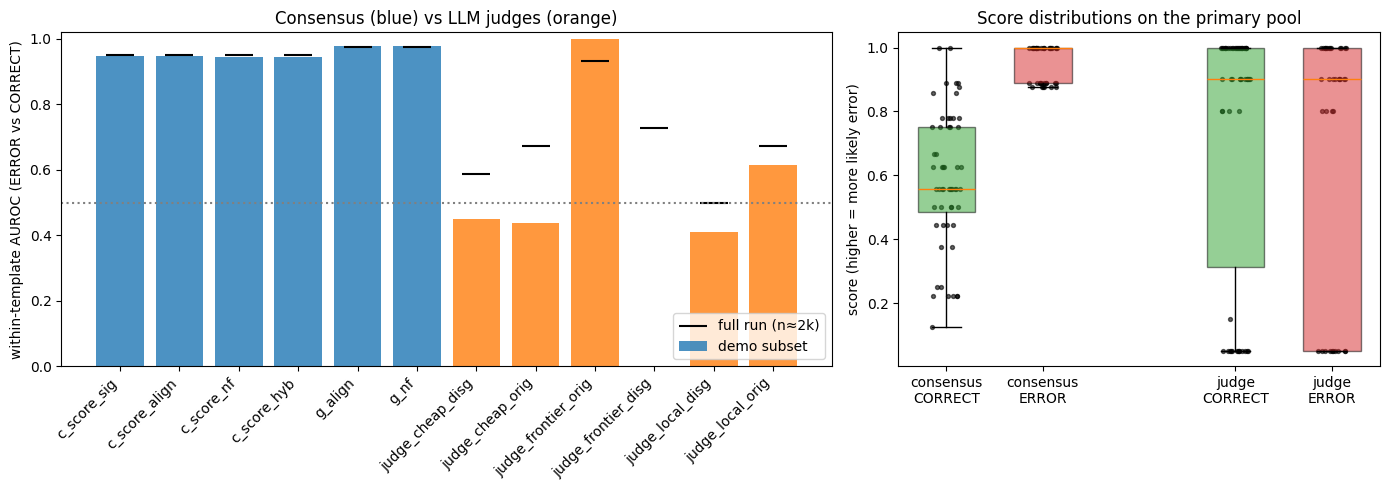

Demo subset: delta AUROC (consensus - disguised judge) = +0.493; full run = +0.367 [0.328, 0.404] (pre-registered PASS = True)


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.6, 1]})
t = tab[tab["metric"] != "c_score_exact_live"].reset_index(drop=True)
x = np.arange(len(t))
col = ["#1f77b4" if m.startswith(("c_", "g_")) else "#ff7f0e" for m in t["metric"]]
ax[0].bar(x, t["auroc_demo"].astype(float).fillna(0), color=col, alpha=0.8, label="demo subset")
ax[0].scatter(x, t["auroc_full"].astype(float), marker="_", s=400, color="k", label="full run (n≈2k)")
for i, v in enumerate(t["auroc_demo"]):
    if v is None or pd.isna(v):
        ax[0].text(i, 0.02, "n/a", ha="center", fontsize=8)
ax[0].axhline(0.5, ls=":", c="grey")
ax[0].set_xticks(x, t["metric"], rotation=45, ha="right")
ax[0].set_ylim(0, 1.02); ax[0].set_ylabel("within-template AUROC (ERROR vs CORRECT)")
ax[0].set_title("Consensus (blue) vs LLM judges (orange)"); ax[0].legend(loc="lower right")

for j, (m, name) in enumerate([("c_score_sig", "consensus c_score_sig"), (PRIMARY_BAR, "judge (disguised, cheap)")]):
    for k, lab in enumerate(["CORRECT", "ERROR"]):
        v = [r[m] for r in pool if r["label"] == lab and r[m] is not None]
        pos = j * 3 + k
        ax[1].boxplot(v, positions=[pos], widths=0.6, patch_artist=True,
                      boxprops=dict(facecolor="#2ca02c" if lab == "CORRECT" else "#d62728", alpha=0.5))
        ax[1].scatter(pos + np.random.default_rng(k).uniform(-0.15, 0.15, len(v)), v, s=8, c="k", alpha=0.6)
ax[1].set_xticks([0, 1, 3, 4], ["consensus\nCORRECT", "consensus\nERROR", "judge\nCORRECT", "judge\nERROR"])
ax[1].set_ylabel("score (higher = more likely error)")
ax[1].set_title("Score distributions on the primary pool")
plt.tight_layout(); plt.show()

print(f"Demo subset: delta AUROC (consensus - disguised judge) = {prim['delta']:+.3f}; full run = {full['delta']:+.3f} "
      f"[{full['ci'][0]:.3f}, {full['ci'][1]:.3f}] (pre-registered PASS = {full['PASS']})")